# Feature Surface Reduction (Lightweight Model)
In this notebook, we extract the Top 100 most important features from our original 2381-feature model. We then train a new lightweight model using **ONLY** these 100 features.

This reduces memory usage by >95% and allows us to train on much larger, more stable chunks of data. By removing 2281 'noisy' features and giving LightGBM larger data partitions to analyze, we can expect a significant increase in AUC and Accuracy.

In [1]:
import os
import sys
import numpy as np
import lightgbm as lgb

# Ensure the paths to the virtual environment(s) are added BEFORE importing packages
base_dir = os.getcwd()
for venv_folder in ["venv", ".venv"]:
    site_packages = os.path.join(base_dir, venv_folder, "Lib", "site-packages")
    if os.path.exists(site_packages) and site_packages not in sys.path:
        sys.path.insert(0, site_packages)
        break

global_venv_site_packages = r"Z:\ai project\.venv\Lib\site-packages"
if os.path.exists(global_venv_site_packages) and global_venv_site_packages not in sys.path:
    sys.path.insert(0, global_venv_site_packages)

try:
    from thrember.features import PEFeatureExtractor
    print("Features extractor imported successfully.")
except ImportError:
    print("Warning: 'thrember' not found. Will use default feature dimension (2381).")
    class PEFeatureExtractor:
        dim = 2381

Z:\ai project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Features extractor imported successfully.


### 1. Extract Top Features
We load the tuned model and extract the indices of the features that provided the highest 'gain' (predictive power). We will grab 150 max.

In [2]:
DATASET_DIR = r"Z:\ember2024_train_data"
orig_model_path = os.path.join(DATASET_DIR, "ember_model_tuned_full.txt")

print(f"Loading original massive model from {orig_model_path}...")
orig_model = lgb.Booster(model_file=orig_model_path)

# Evaluate feature importance based on 'gain' (which measures the improvement in accuracy a feature brings)
importances = orig_model.feature_importance(importance_type='gain')

# Get the indices of the top 150 features, sorted highest to lowest
top_indices_all = np.argsort(importances)[::-1][:150]

print("\n🏆 Top 150 Feature Indices extracted!")
print(top_indices_all)

Loading original massive model from Z:\ember2024_train_data\ember_model_tuned_full.txt...

🏆 Top 150 Feature Indices extracted!
[ 881 1026  166  220  602 1444 2442  524  595   40   18 1395  711  562
  423  714 1663 2443  522  529  542   57  741  652 2405  913  684 2540
  361  587   27 2479  200  538  163   47  779  723   77  739  278  992
  543  550  502 2547  754  561  330 2459  743  253  287  140 2466  146
 2450  662  573  872  422  203 2409   90  519  472  566  635  637  477
  242  503  612  594  408  409  991  588 1722  664 1833  734  697  689
  924  572 1457 2406  150 2407  151  993  354  720  874  548 2413    0
  521  605  262  161  710   10  499   59   71  583  125  406  407  745
  169  399 1612 2121  504  645  571  667  677  589  331  567  440  596
  994  773  537  170  551  775  686  597  456 2439   64  721   93   43
 2412  668  117  696  141 2567  238  496  680   98]


### 2. Setup Reduced Data Loader
We will load data in chunks from the `.dat` file, but we will instantly slice the array to just those 150 columns before feeding it to LightGBM. Because the data width is reduced by 95%, we can securely bump `CHUNK_SIZE` up to **250,000 rows** without crashing.

In [3]:
X_path = os.path.join(DATASET_DIR, "X_train.dat")
y_path = os.path.join(DATASET_DIR, "y_train.dat")

extractor = PEFeatureExtractor()
ndim = extractor.dim

file_size = os.path.getsize(X_path)
nrows = file_size // (ndim * 4)

# Memory map the raw arrays
X_memmap = np.memmap(X_path, dtype=np.float32, mode="r", shape=(nrows, ndim))
y_memmap = np.memmap(y_path, dtype=np.int32, mode="r", shape=(nrows,))

train_nrows = int(nrows * 0.9)
print(f"Dataset ready. Training strictly on {train_nrows} records.")

Dataset ready. Training strictly on 4726800 records.


### 3. Train the Lightweight Model

ALLOCATING RAM FOR FULL 150-FEATURE DATASET (~2.7 GB)...
Scanning disk for top 150 features across 4726800 rows...
  -> Loaded 200000 / 4726800 rows into memory...
  -> Loaded 400000 / 4726800 rows into memory...
  -> Loaded 600000 / 4726800 rows into memory...
  -> Loaded 800000 / 4726800 rows into memory...
  -> Loaded 1000000 / 4726800 rows into memory...
  -> Loaded 1200000 / 4726800 rows into memory...
  -> Loaded 1400000 / 4726800 rows into memory...
  -> Loaded 1600000 / 4726800 rows into memory...
  -> Loaded 1800000 / 4726800 rows into memory...
  -> Loaded 2000000 / 4726800 rows into memory...
  -> Loaded 2200000 / 4726800 rows into memory...
  -> Loaded 2400000 / 4726800 rows into memory...
  -> Loaded 2600000 / 4726800 rows into memory...
  -> Loaded 2800000 / 4726800 rows into memory...
  -> Loaded 3000000 / 4726800 rows into memory...
  -> Loaded 3200000 / 4726800 rows into memory...
  -> Loaded 3400000 / 4726800 rows into memory...
  -> Loaded 3600000 / 4726800 rows into

,Num Features,Training Duration (s),Model Path,Indices
0,75,603.52,Z:\ember2024_train_data\ember_model_reduced_75...,Z:\ember2024_train_data\ember_reduced_75_indic...
1,100,1069.54,Z:\ember2024_train_data\ember_model_reduced_10...,Z:\ember2024_train_data\ember_reduced_100_indi...
2,125,1330.89,Z:\ember2024_train_data\ember_model_reduced_12...,Z:\ember2024_train_data\ember_reduced_125_indi...
3,150,964.71,Z:\ember2024_train_data\ember_model_reduced_15...,Z:\ember2024_train_data\ember_reduced_150_indi...


📄 Report saved to: Z:\ember2024_train_data\feature_reduction_training_report.csv


C:\Users\him\AppData\Local\Temp\ipykernel_12016\4161740928.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=df_results, x='Num Features', y='Training Duration (s)', palette='crest')


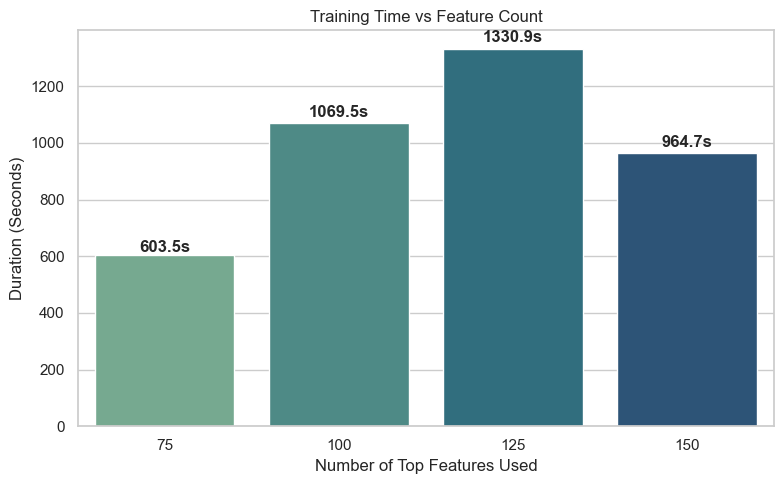

In [4]:
import gc
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

print("ALLOCATING RAM FOR FULL 150-FEATURE DATASET (~2.7 GB)...")
# By pre-allocating, we prevent NumPy from duplicating massive arrays in memory
X_train_full = np.empty((train_nrows, 150), dtype=np.float32)
y_train_full = np.empty((train_nrows,), dtype=np.int32)

# Safely load the 150 features off the disk in small chunks, directly into our pre-allocated RAM
CHUNK_SIZE = 20000  # Smaller chunks to ensure low RAM spikes and visible progress
print(f"Scanning disk for top 150 features across {train_nrows} rows...")
for start_idx in range(0, train_nrows, CHUNK_SIZE):
    end_idx = min(start_idx + CHUNK_SIZE, train_nrows)
    
    # Pull chunk into RAM first before advanced indexing
    chunk_temp = np.array(X_memmap[start_idx:end_idx]) 
    X_train_full[start_idx:end_idx] = chunk_temp[:, top_indices_all]
    y_train_full[start_idx:end_idx] = y_memmap[start_idx:end_idx]
    
    del chunk_temp  # Free chunk immediately
    
    # Update more frequently so you know it's not frozen
    if end_idx % 200000 == 0 or end_idx == train_nrows:
        print(f"  -> Loaded {end_idx} / {train_nrows} rows into memory...")

print("Data loaded! Removing unlabeled (-1) samples...")
valid_mask = y_train_full != -1
X_train_full = X_train_full[valid_mask]
y_train_full = y_train_full[valid_mask]

# Clean up temporary mask
del valid_mask
gc.collect()

feature_counts = [75, 100, 125, 150]
results = []
original_categoricals = [2, 3, 4, 5, 6, 701, 702]

for num_fe in feature_counts:
    print(f"\n{'='*60}\n🚀 TRAINING WITH TOP {num_fe} FEATURES\n{'='*60}")
    
    # Slice the pre-loaded 150-feature array down to just num_fe features
    # Because we took the top 150 in sorted order, the first num_fe are the top num_fe.
    current_indices = top_indices_all[:num_fe]
    current_X_train = X_train_full[:, :num_fe]  # This is a zero-copy pointer/view, very fast!
    
    # Map index categoricals dynamically
    reduced_categoricals = []
    for i, original_idx in enumerate(current_indices):
        if original_idx in original_categoricals:
            reduced_categoricals.append(i)
    
    print(f"Mapped {len(reduced_categoricals)} categorical features for this run: {reduced_categoricals}")

    print("Creating LightGBM Dataset...")
    train_data = lgb.Dataset(
        current_X_train, 
        label=y_train_full, 
        categorical_feature=reduced_categoricals,
        free_raw_data=False
    )

    params = {
        "objective": "binary",
        "boosting_type": "gbdt",
        "learning_rate": 0.05,
        "num_leaves": 1024,
        "max_depth": 15,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 5,
        "verbose": -1,
        "n_jobs": -1
    }

    start_time = time.time()
    reduced_model = lgb.train(
        params,
        train_data,
        num_boost_round=150
    )
    duration = time.time() - start_time
    print(f"✅ Training took {duration:.2f} seconds.")

    # Save model and indices right after training
    final_save_path = os.path.join(DATASET_DIR, f"ember_model_reduced_{num_fe}.txt")
    reduced_model.save_model(final_save_path)
    
    indices_path = os.path.join(DATASET_DIR, f"ember_reduced_{num_fe}_indices.npy")
    np.save(indices_path, current_indices)
    
    print(f"💾 Model securely saved to: {final_save_path}")
    
    results.append({
        "Num Features": num_fe,
        "Training Duration (s)": round(duration, 2),
        "Model Path": final_save_path,
        "Indices": indices_path
    })
    
    # Cleanup memory before next size loop
    del train_data
    del reduced_model
    gc.collect()

print("\n🎉 ALL TRAINING COMPLETE! Summary:")
df_results = pd.DataFrame(results)
display(df_results)

# Save to CSV
report_path = os.path.join(DATASET_DIR, "feature_reduction_training_report.csv")
df_results.to_csv(report_path, index=False)
print(f"📄 Report saved to: {report_path}")

# Plot Validation visual output
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
plot = sns.barplot(data=df_results, x='Num Features', y='Training Duration (s)', palette='crest')
plt.title('Training Time vs Feature Count')
plt.ylabel('Duration (Seconds)')
plt.xlabel('Number of Top Features Used')

# Add exact time labels above the bars
for index, value in enumerate(df_results['Training Duration (s)']):
    plot.text(index, value + (value * 0.02), f"{value:.1f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()